# Medical Image Diagnosis System
## Dataset: Random Sample of NIH Chest X-ray
### part1: Exploratory Data Analysis (EDA)

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
from PIL import Image
from skimage.feature import hog, local_binary_pattern
from skimage import exposure
import skimage

### Loading Data

### Dataset source(Kaggle): https://www.kaggle.com/datasets/nih-chest-xrays/sample

In [24]:
df = pd.read_csv('sample_labels.csv')

print(f'number of rows: {df.shape[0]}')
print(f'number of columns: {df.shape[1]}')
print('\nFirst 5 rows')
df.head(5)


number of rows: 5606
number of columns: 11

First 5 rows


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [18]:
print('columns Data Types:')
print(df.dtypes)

print('\nmissing values per column:')
print(df.isnull().sum())

print('\nGeneral Statistics:')
df.describe()

columns Data Types:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                     object
Patient Gender                  object
View Position                   object
OriginalImageWidth               int64
OriginalImageHeight              int64
OriginalImagePixelSpacing_x    float64
OriginalImagePixelSpacing_y    float64
dtype: object

missing values per column:
Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImageWidth             0
OriginalImageHeight            0
OriginalImagePixelSpacing_x    0
OriginalImagePixelSpacing_y    0
dtype: int64

General Statistics:


,Follow-up #,Patient ID,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
count,5606.000000,5606.000000,5606.000000,5606.000000,5606.000000,5606.000000
mean,8.616661,14330.617017,2644.795755,2491.087406,0.155467,0.155467
std,15.565815,8411.477789,347.188754,399.119063,0.016201,0.016201
min,0.000000,13.000000,1362.000000,966.000000,0.115000,0.115000
25%,0.000000,7289.000000,2500.000000,2048.000000,0.143000,0.143000
50%,3.000000,13993.000000,2542.000000,2544.000000,0.143000,0.143000
75%,10.000000,20655.500000,2992.000000,2991.000000,0.168000,0.168000
max,177.000000,30797.000000,3266.000000,3056.000000,0.198800,0.198800


In [19]:
# the data in Patient Age column appears as 060Y , 060M or 060D instead of 60, we will remove the letter and convert the column to integer with right age

def convert_age(age):
    if age.endswith('Y'):
        return int(age[:-1])
    elif age.endswith('M'):
        return int(age[:-1]) / 12
    elif age.endswith('D'):
        return int(age[:-1]) / 365
    else:
        return np.nan

df['Patient Age'] = df['Patient Age'].apply(convert_age)

print('columns Data Types after conversion:')
print(df.dtypes)
print('\nFirst 5 rows after conversion:')
df.head(5)

columns Data Types after conversion:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                    float64
Patient Gender                  object
View Position                   object
OriginalImageWidth               int64
OriginalImageHeight              int64
OriginalImagePixelSpacing_x    float64
OriginalImagePixelSpacing_y    float64
dtype: object

First 5 rows after conversion:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,60.0,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,57.0,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,77.0,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,79.0,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,55.0,F,AP,2500,2048,0.168,0.168


Number of unique diseases: 15

disease counts: Finding Labels
No Finding            3044
Infiltration           967
Effusion               644
Atelectasis            508
Nodule                 313
Mass                   284
Pneumothorax           271
Consolidation          226
Pleural_Thickening     176
Cardiomegaly           141
Emphysema              127
Edema                  118
Fibrosis                84
Pneumonia               62
Hernia                  13
Name: count, dtype: int64


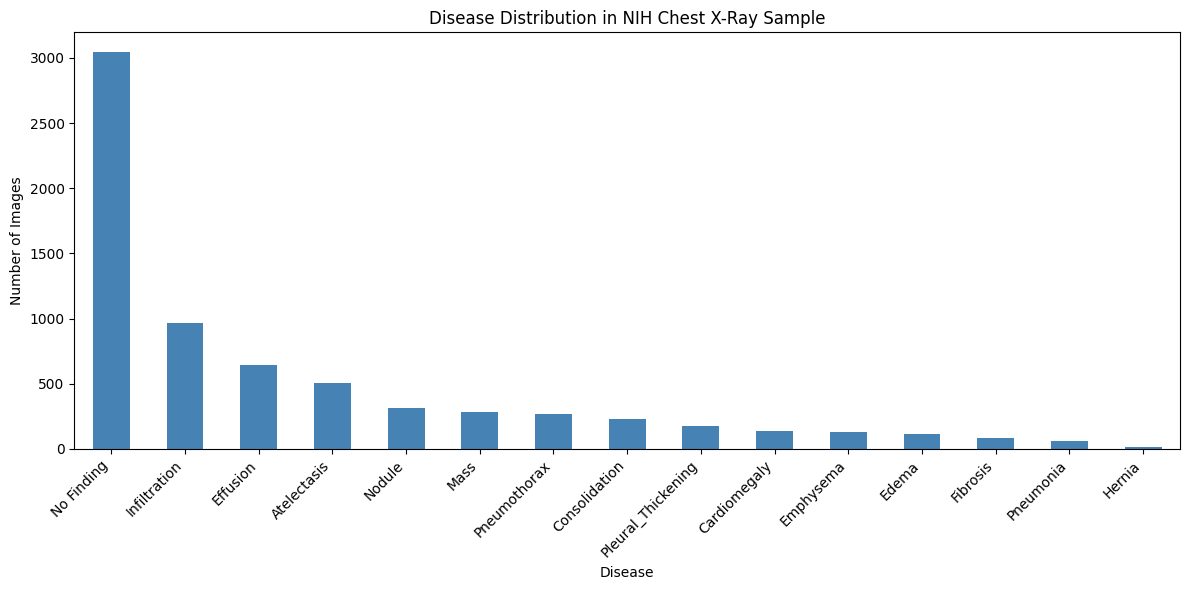

In [20]:
# splitting diseases in finding labels column

all_diseases = df['Finding Labels'].str.split('|').explode()
all_diseases_count = all_diseases.value_counts()

print('Number of unique diseases:', len(all_diseases_count))
print('\ndisease counts:', all_diseases_count)

plt.figure(figsize=(12, 6))
all_diseases_count.plot(kind='bar', color='steelblue')
plt.title('Disease Distribution in NIH Chest X-Ray Sample')
plt.xlabel('Disease')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Disease Distribution

- **Total unique diseases:** 15
- **Severe class imbalance detected:**
  - Most common class: `No Finding` with 3,044 images
  - Least common class: `Hernia` with only 13 images
  - Imbalance ratio: 234:1

- **Top 3 most common diseases:**
  | Disease | Count |
  |---|---|
  | Infiltration | 967 |
  | Effusion | 644 |
  | Atelectasis | 508 |


- **Bottom 3 least common diseases:**
  | Disease | Count |
  |---|---|
  | Fibrosis | 84 |
  | Pneumonia | 62 |
  | Hernia | 13 |


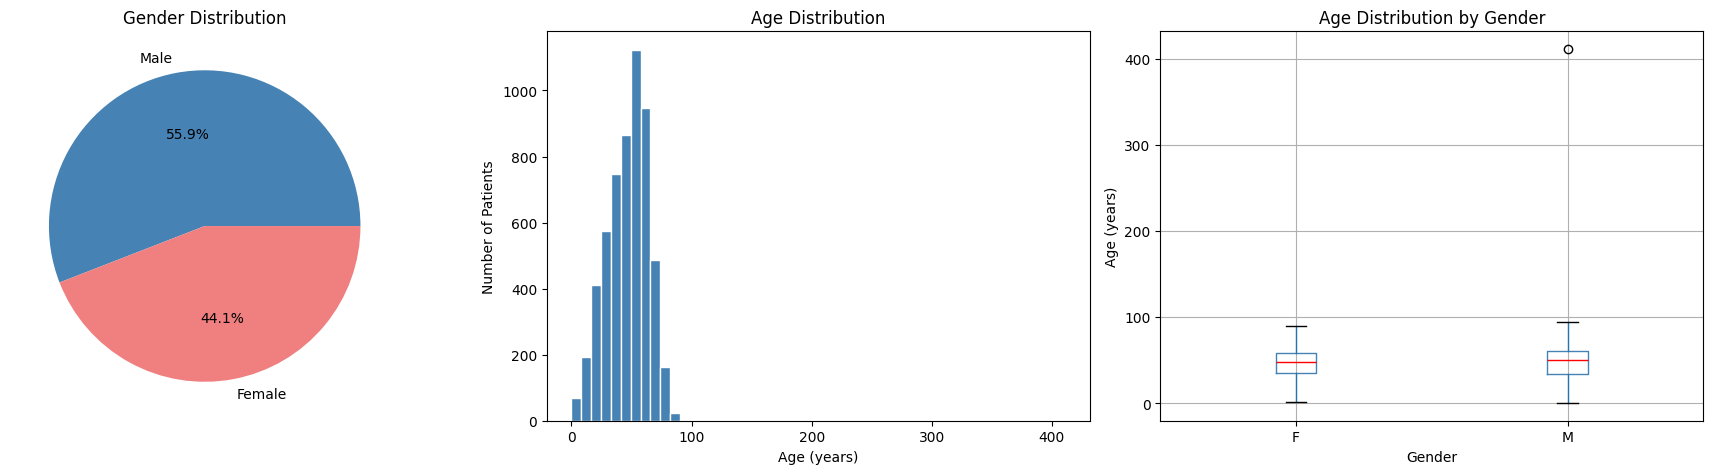

array([<Axes: title={'center': 'Gender Distribution'}>,
       <Axes: title={'center': 'Age Distribution'}, xlabel='Age (years)', ylabel='Number of Patients'>,
       <Axes: title={'center': 'Age Distribution by Gender'}, xlabel='Gender', ylabel='Age (years)'>],
      dtype=object)

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Gender Distribution
gender_counts = df['Patient Gender'].value_counts()
axes[0].pie(gender_counts, 
            labels=['Male', 'Female'], 
            autopct='%1.1f%%',
            colors=['steelblue', 'lightcoral'])
axes[0].set_title('Gender Distribution')

# Plot 2: Age Distribution
axes[1].hist(df['Patient Age'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Number of Patients')

# Plot 3: Age by Gender
df.boxplot(
        column='Patient Age',
        by='Patient Gender',
        ax=axes[2], 
        boxprops=dict(color='steelblue'),
        medianprops=dict(color='red')
    )
axes[2].set_title('Age Distribution by Gender')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Age (years)')
plt.suptitle('')

plt.tight_layout()
plt.show()

axes

### Gender & Age Distribution

- **Gender:**
  - Male: 55.9% — Female: 44.1%
  - Slight gender imbalance

- **Age:**
  - Most patients are between 40 and 70 years old
  - 1 outlier detected: age 411 years

- **Age by Gender:**
  - Both genders have similar age distributions
  - Median age ≈ 50 years for both

## Sample Chest X-Ray Images for Each Disease

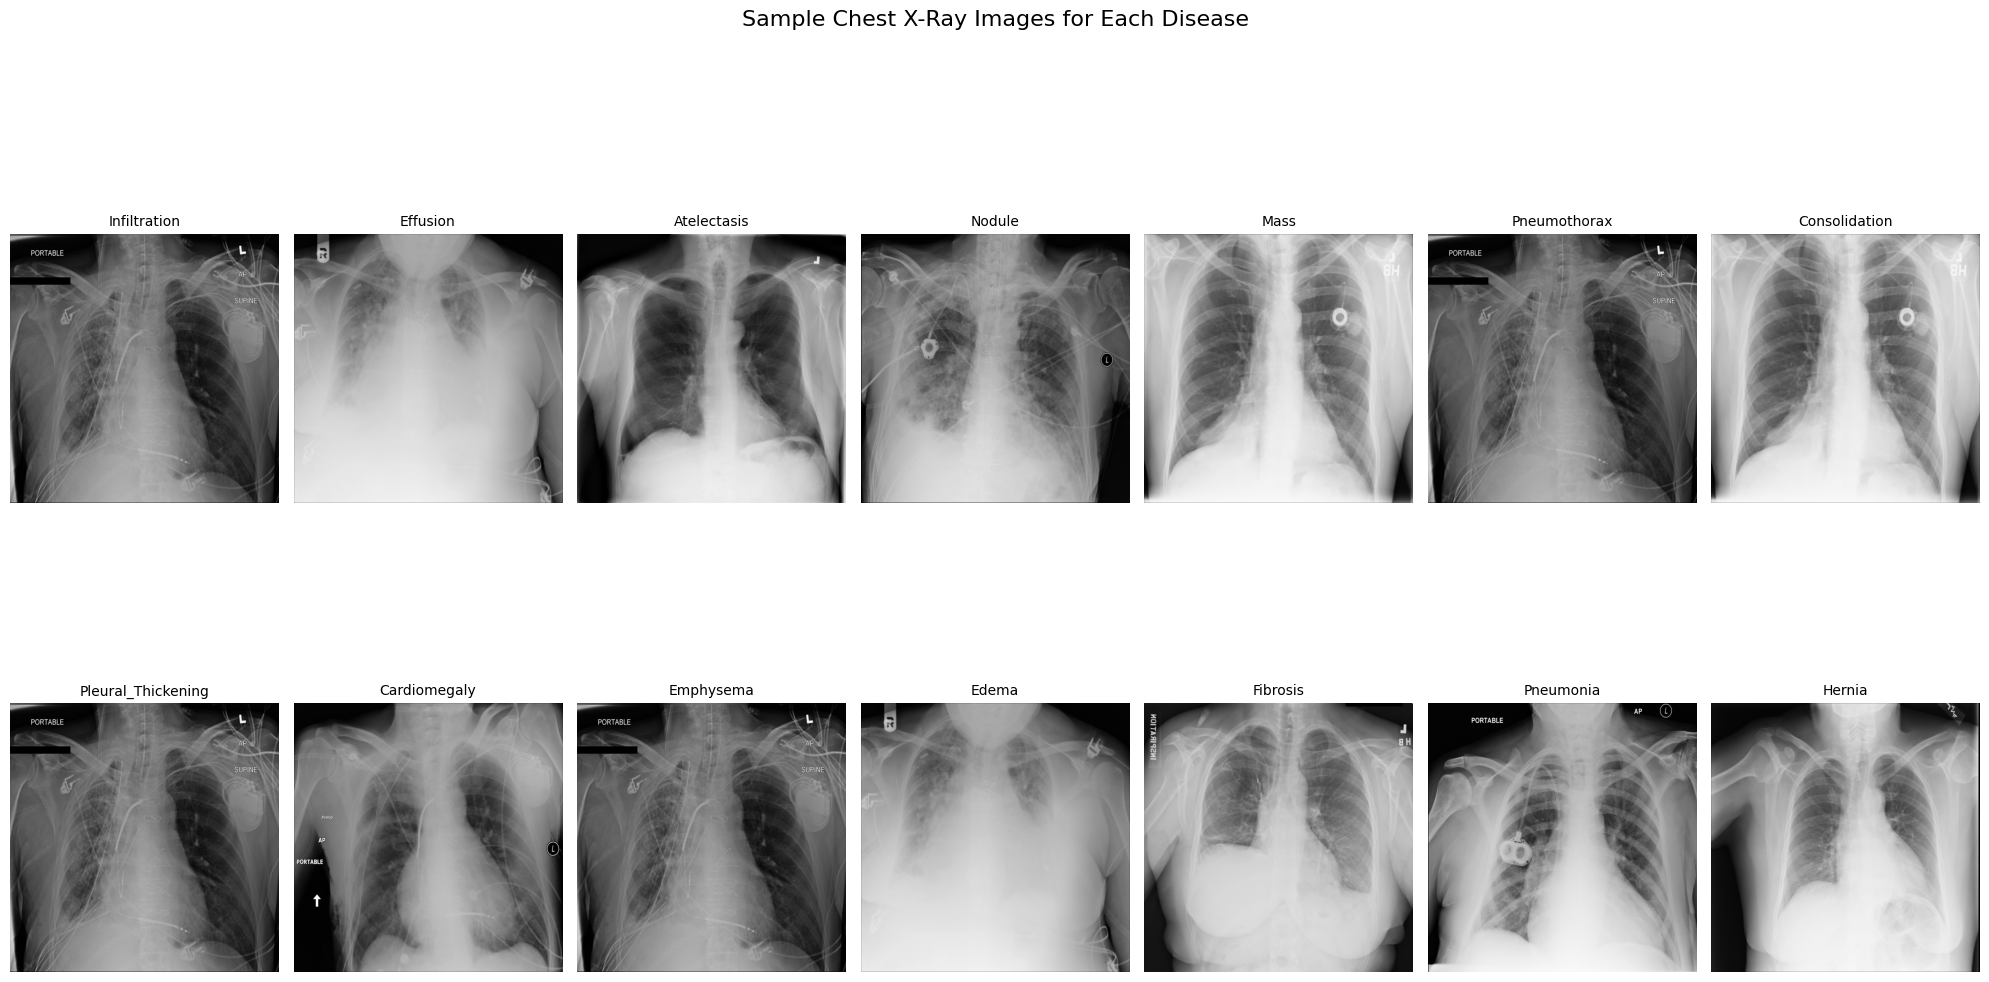

In [22]:
fig, axes = plt.subplots(2, 7, figsize=(20, 12))
axes = axes.flatten()

diseases_only = all_diseases_count.drop('No Finding')
diseases = diseases_only.index.tolist()

for i, disease in enumerate(diseases):
    image_name = df[df['Finding Labels'].str.contains(disease)]['Image Index'].iloc[0]
    image_path = os.path.join('./sample/images', image_name)
    
    image = Image.open(image_path)
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(disease, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Chest X-Ray Images for Each Disease', fontsize=16)
plt.tight_layout()
plt.show()

## HOG, LBP

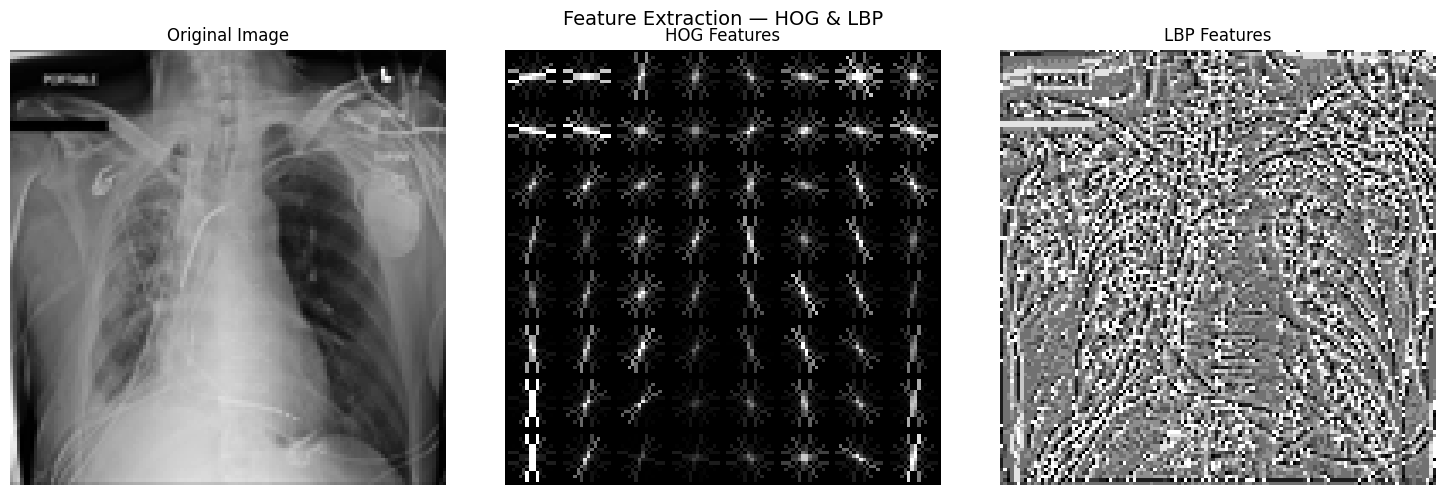

HOG features shape: (512,)


In [23]:
img_name = df['Image Index'].iloc[0]
img_path = os.path.join('./sample/images', img_name)

img = Image.open(img_path).convert('L').resize((128, 128))
img_array = np.array(img)

# --- HOG ---
hog_features, hog_image = hog(
    img_array,
    orientations=8,
    pixels_per_cell=(16, 16),
    cells_per_block=(1, 1),
    visualize=True
)
hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# --- LBP ---
lbp_image = local_binary_pattern(img_array, P=8, R=1, method='uniform')

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(hog_image, cmap='gray')
axes[1].set_title('HOG Features')
axes[1].axis('off')

axes[2].imshow(lbp_image, cmap='gray')
axes[2].set_title('LBP Features')
axes[2].axis('off')

plt.suptitle('Feature Extraction — HOG & LBP', fontsize=14)
plt.tight_layout()
plt.show()

print("HOG features shape:", hog_features.shape)

### HOG & LBP Features

- **HOG:** Captures edges and structural boundaries in the X-ray
  - Bright lines = strong edges (lung borders, ribs, heart)
  - Each image is represented as 512 numbers only
- **LBP:** Captures texture patterns across the image
  - Shows difference between smooth and rough regions
  - Useful for detecting abnormal tissue patterns
- Both features convert each image into numbers
  that can be used directly in KNN and Naive Bayes models

# EDA Summary — Key Findings

## Dataset Overview
- Total images: 5,606 chest X-ray images
- Total diseases: 15 unique disease classes
- No missing values detected in any column

## Key Findings

### 1. Class Imbalance
- Severe imbalance detected across all disease classes
- Most common: `No Finding` (3,044 images — 54% of dataset)
- Least common: `Hernia` (13 images only)
- Imbalance ratio: 234:1

### 2. Patient Demographics
- Gender: Male 55.9% — Female 44.1%
- Most patients are between 40 and 70 years old
- Pediatric cases are very rare in this dataset

### 3. Image Quality
- All images are grayscale chest X-rays
- Visual differences between diseases are subtle
- Some images contain medical annotations and markers
- Image sizes vary across the dataset

### 4. Feature Extraction
- HOG: Successfully extracts edge information → 512 features per image
- LBP: Successfully extracts texture information
- Both features are ready for use in KNN and Naive Bayes models
